# IVF Pregnancy Prediction Pipeline v7

## 실행 결과 분석 및 주요 업데이트

### CV vs 리더보드 갭 원인 분석 및 해결
**실행 결과에서 확인된 문제점 및 개선 사항:**
1. **IQR 클리핑 전략 수정**: 
    - 기존의 IQR 클리핑이 너무 Aggressive하여 '총 시술 횟수', '총 임신 횟수' 등 주요 수치형 변수가 단일값으로 고정되는 현상 발견.
    - **수정**: 과도한 클리핑을 제거하고, 생물학적/상식적 범위를 벗어나는 수치에 대해서만 상하한(Manual Clipping)을 적용하여 변수의 변별력 회복.
2. **고결측 컬럼 및 노이즈 제거**:
    - 결측률 96~99%인 '난자 해동 경과일', '임신 시도 경과 연수' 등은 단순 Median 대치 시 정보량이 0에 가까움.
    - **수정**: 결측률이 매우 높은 컬럼은 유지하는 대신 정보 손실을 최소화하는 방향으로 전처리 전략 수정.
3. **CatBoost 범주형 변수 처리 오류 해결**:
    - 실수형(float)으로 변환된 '나이' 등의 컬럼이 범주형 인덱스에 포함되어 발생하던 `CatBoostError` 해결.
    - 수치형으로 의미가 있는 변수(나이, 횟수 등)는 범주형 인덱스에서 제외하여 모델의 학습 효율 증대.

### v8 핵심 수정
1. **전처리 파이프라인 최적화**
    - **IQR 클리핑 제거**: 수치형 데이터의 분포를 살리기 위해 바이오 상한/하한 위주의 완만한 클리핑 적용.
    - **파생변수 고도화**: 논문 기반의 임신 성공률, 실패율 및 누적 성공 지표(Proxy)의 계산 로직 정상화.
2. **모델 튜닝 전략 고도화 (Efficiency First)**
    - **Optuna 효율화**: 무조건적인 Trial 증가 대신, v7 결과에 기반한 **Search Space 최적화**.
    - **LGBM**: 50 Trials (3-Fold로 튜닝 속도 확보, 불필요한 Depth 탐색 제한).
    - **CatBoost**: 60 Trials (GPU P100 가속 활용, `logging_level='Silent'` 적용으로 로그 노이즈 제거).
3. **검증 전략 (Validation Strategy)**
    - **Quick CV**: 모델 간 성능 비교 시 `StratifiedKFold`를 활용해 빠른 의사결정 지원.
    - **검증 신뢰도**: 튜닝 단계에서는 속도를 위해 3-Fold를 사용하되, 최종 모델링 시 Fold 수를 조절하여 안정적인 OOF(Out-of-Fold) 예측값 생성.
4. **CatBoost Native Categorical 최적화**
    - `cat_features` 인덱스를 정교하게 추출하여 CatBoost 고유의 범주형 처리 알고리즘 활용도 극대화.


## 설치

In [1]:
!pip install koreanize-matplotlib optuna catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 16.4 MB/s eta 0:00:0000:0100:01


## 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import time

import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['axes.unicode_minus'] = False
optuna.logging.set_verbosity(optuna.logging.WARNING)


## 데이터 로드

In [3]:
train = pd.read_csv("/kaggle/input/datasets/mkim98/fertility-dataset/train.csv")
test  = pd.read_csv("/kaggle/input/datasets/mkim98/fertility-dataset/test.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print(f"Train: {train.shape}, Test: {test.shape}")


Train: (256351, 69), Test: (90067, 68)


## 데이터 탐색

In [4]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  object 
 1   시술 시기 코드               256351 non-null  object 
 2   시술 당시 나이               256351 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  object 
 5   특정 시술 유형               256349 non-null  object 
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  object 
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-nu

In [5]:
train.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
임신 시도 또는 마지막 임신 경과 연수,9370.0,9.270651,3.550313,0.0,7.0,9.0,11.0,20.0
배란 자극 여부,256351.0,0.771286,0.420005,0.0,1.0,1.0,1.0,1.0
단일 배아 이식 여부,250060.0,0.233476,0.423043,0.0,0.0,0.0,0.0,1.0
착상 전 유전 검사 사용 여부,2718.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
착상 전 유전 진단 사용 여부,250060.0,0.012781,0.112328,0.0,0.0,0.0,0.0,1.0
남성 주 불임 원인,256351.0,0.028516,0.166441,0.0,0.0,0.0,0.0,1.0
남성 부 불임 원인,256351.0,0.013115,0.113767,0.0,0.0,0.0,0.0,1.0
여성 주 불임 원인,256351.0,0.030724,0.172568,0.0,0.0,0.0,0.0,1.0
여성 부 불임 원인,256351.0,0.012432,0.110805,0.0,0.0,0.0,0.0,1.0
부부 주 불임 원인,256351.0,0.033068,0.178814,0.0,0.0,0.0,0.0,1.0


In [6]:
train.describe(include="object").T


,count,unique,top,freq
ID,256351,256351,TRAIN_256350,1
시술 시기 코드,256351,7,TRDQAZ,38969
시술 당시 나이,256351,7,만18-34세,102476
시술 유형,256351,2,IVF,250060
특정 시술 유형,256349,24,ICSI,122368
배란 유도 유형,256351,4,기록되지 않은 시행,194432
배아 생성 주요 이유,250060,13,현재 시술용,233732
총 시술 횟수,256351,7,0회,97599
클리닉 내 총 시술 횟수,256351,7,0회,121675
IVF 시술 횟수,256351,7,0회,103934


In [7]:
test.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
임신 시도 또는 마지막 임신 경과 연수,3297.0,9.340916,3.639339,0.0,7.0,9.0,12.0,20.0
배란 자극 여부,90067.0,0.774490,0.417920,0.0,1.0,1.0,1.0,1.0
단일 배아 이식 여부,87891.0,0.232788,0.422611,0.0,0.0,0.0,0.0,1.0
착상 전 유전 검사 사용 여부,933.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
착상 전 유전 진단 사용 여부,87891.0,0.012936,0.113001,0.0,0.0,0.0,0.0,1.0
남성 주 불임 원인,90067.0,0.028956,0.167684,0.0,0.0,0.0,0.0,1.0
남성 부 불임 원인,90067.0,0.012868,0.112706,0.0,0.0,0.0,0.0,1.0
여성 주 불임 원인,90067.0,0.030455,0.171837,0.0,0.0,0.0,0.0,1.0
여성 부 불임 원인,90067.0,0.012624,0.111645,0.0,0.0,0.0,0.0,1.0
부부 주 불임 원인,90067.0,0.033309,0.179442,0.0,0.0,0.0,0.0,1.0


In [8]:
def missing_summary(df, name):
    mis = df.isnull().sum()
    mis = mis[mis > 0].sort_values(ascending=False)
    if len(mis) == 0:
        print(f"[{name}] 결측치 없음"); return
    pct = (mis / len(df) * 100).round(2)
    print(pd.DataFrame({"결측 수": mis, "결측률(%)": pct}).to_string())

missing_summary(train, "Train")
missing_summary(test,  "Test")


                         결측 수  결측률(%)
난자 해동 경과일              254915   99.44
PGS 시술 여부              254422   99.25
PGD 시술 여부              254172   99.15
착상 전 유전 검사 사용 여부       253633   98.94
임신 시도 또는 마지막 임신 경과 연수  246981   96.34
배아 해동 경과일              215982   84.25
난자 채취 경과일               57488   22.43
난자 혼합 경과일               53735   20.96
배아 이식 경과일               43566   16.99
저장된 배아 수                 6291    2.45
단일 배아 이식 여부              6291    2.45
배아 생성 주요 이유              6291    2.45
착상 전 유전 진단 사용 여부         6291    2.45
총 생성 배아 수                6291    2.45
미세주입된 난자 수               6291    2.45
기증 배아 사용 여부              6291    2.45
해동 난자 수                  6291    2.45
미세주입 후 저장된 배아 수          6291    2.45
해동된 배아 수                 6291    2.45
미세주입 배아 이식 수             6291    2.45
이식된 배아 수                 6291    2.45
미세주입에서 생성된 배아 수          6291    2.45
수집된 신선 난자 수              6291    2.45
파트너 정자와 혼합된 난자 수         6291    2.45
신선 배아 사용 여부              6291    2.45
동결 배아 사용 여부 

In [9]:
for col in train.select_dtypes(include="object").columns:
    print(f"\n[{col}]")
    print(train[col].value_counts(dropna=False).head(10).to_string())



[ID]
ID
TRAIN_256350    1
TRAIN_000000    1
TRAIN_000001    1
TRAIN_000002    1
TRAIN_000003    1
TRAIN_000004    1
TRAIN_000005    1
TRAIN_000006    1
TRAIN_000007    1
TRAIN_000008    1

[시술 시기 코드]
시술 시기 코드
TRDQAZ    38969
TRCMWS    38090
TRYBLT    36713
TRVNRY    36173
TRJXFG    36031
TRZKPL    35544
TRXQMD    34831

[시술 당시 나이]
시술 당시 나이
만18-34세    102476
만35-37세     57780
만38-39세     39247
만40-42세     37348
만43-44세     12253
만45-50세      6918
알 수 없음        329

[시술 유형]
시술 유형
IVF    250060
DI       6291

[특정 시술 유형]
특정 시술 유형
ICSI                  122368
IVF                    91755
Unknown                26939
IUI                     6100
ICSI:ICSI               2314
ICSI / BLASTOCYST       1609
IVF / BLASTOCYST        1248
IVF:IVF                 1146
ICSI:IVF                 873
ICSI / AH                769

[배란 유도 유형]
배란 유도 유형
기록되지 않은 시행      194432
알 수 없음           61917
세트로타이드 (억제제)         1
생식선 자극 호르몬           1

[배아 생성 주요 이유]
배아 생성 주요 이유
현재 시술용                 233732
배아 저장용 

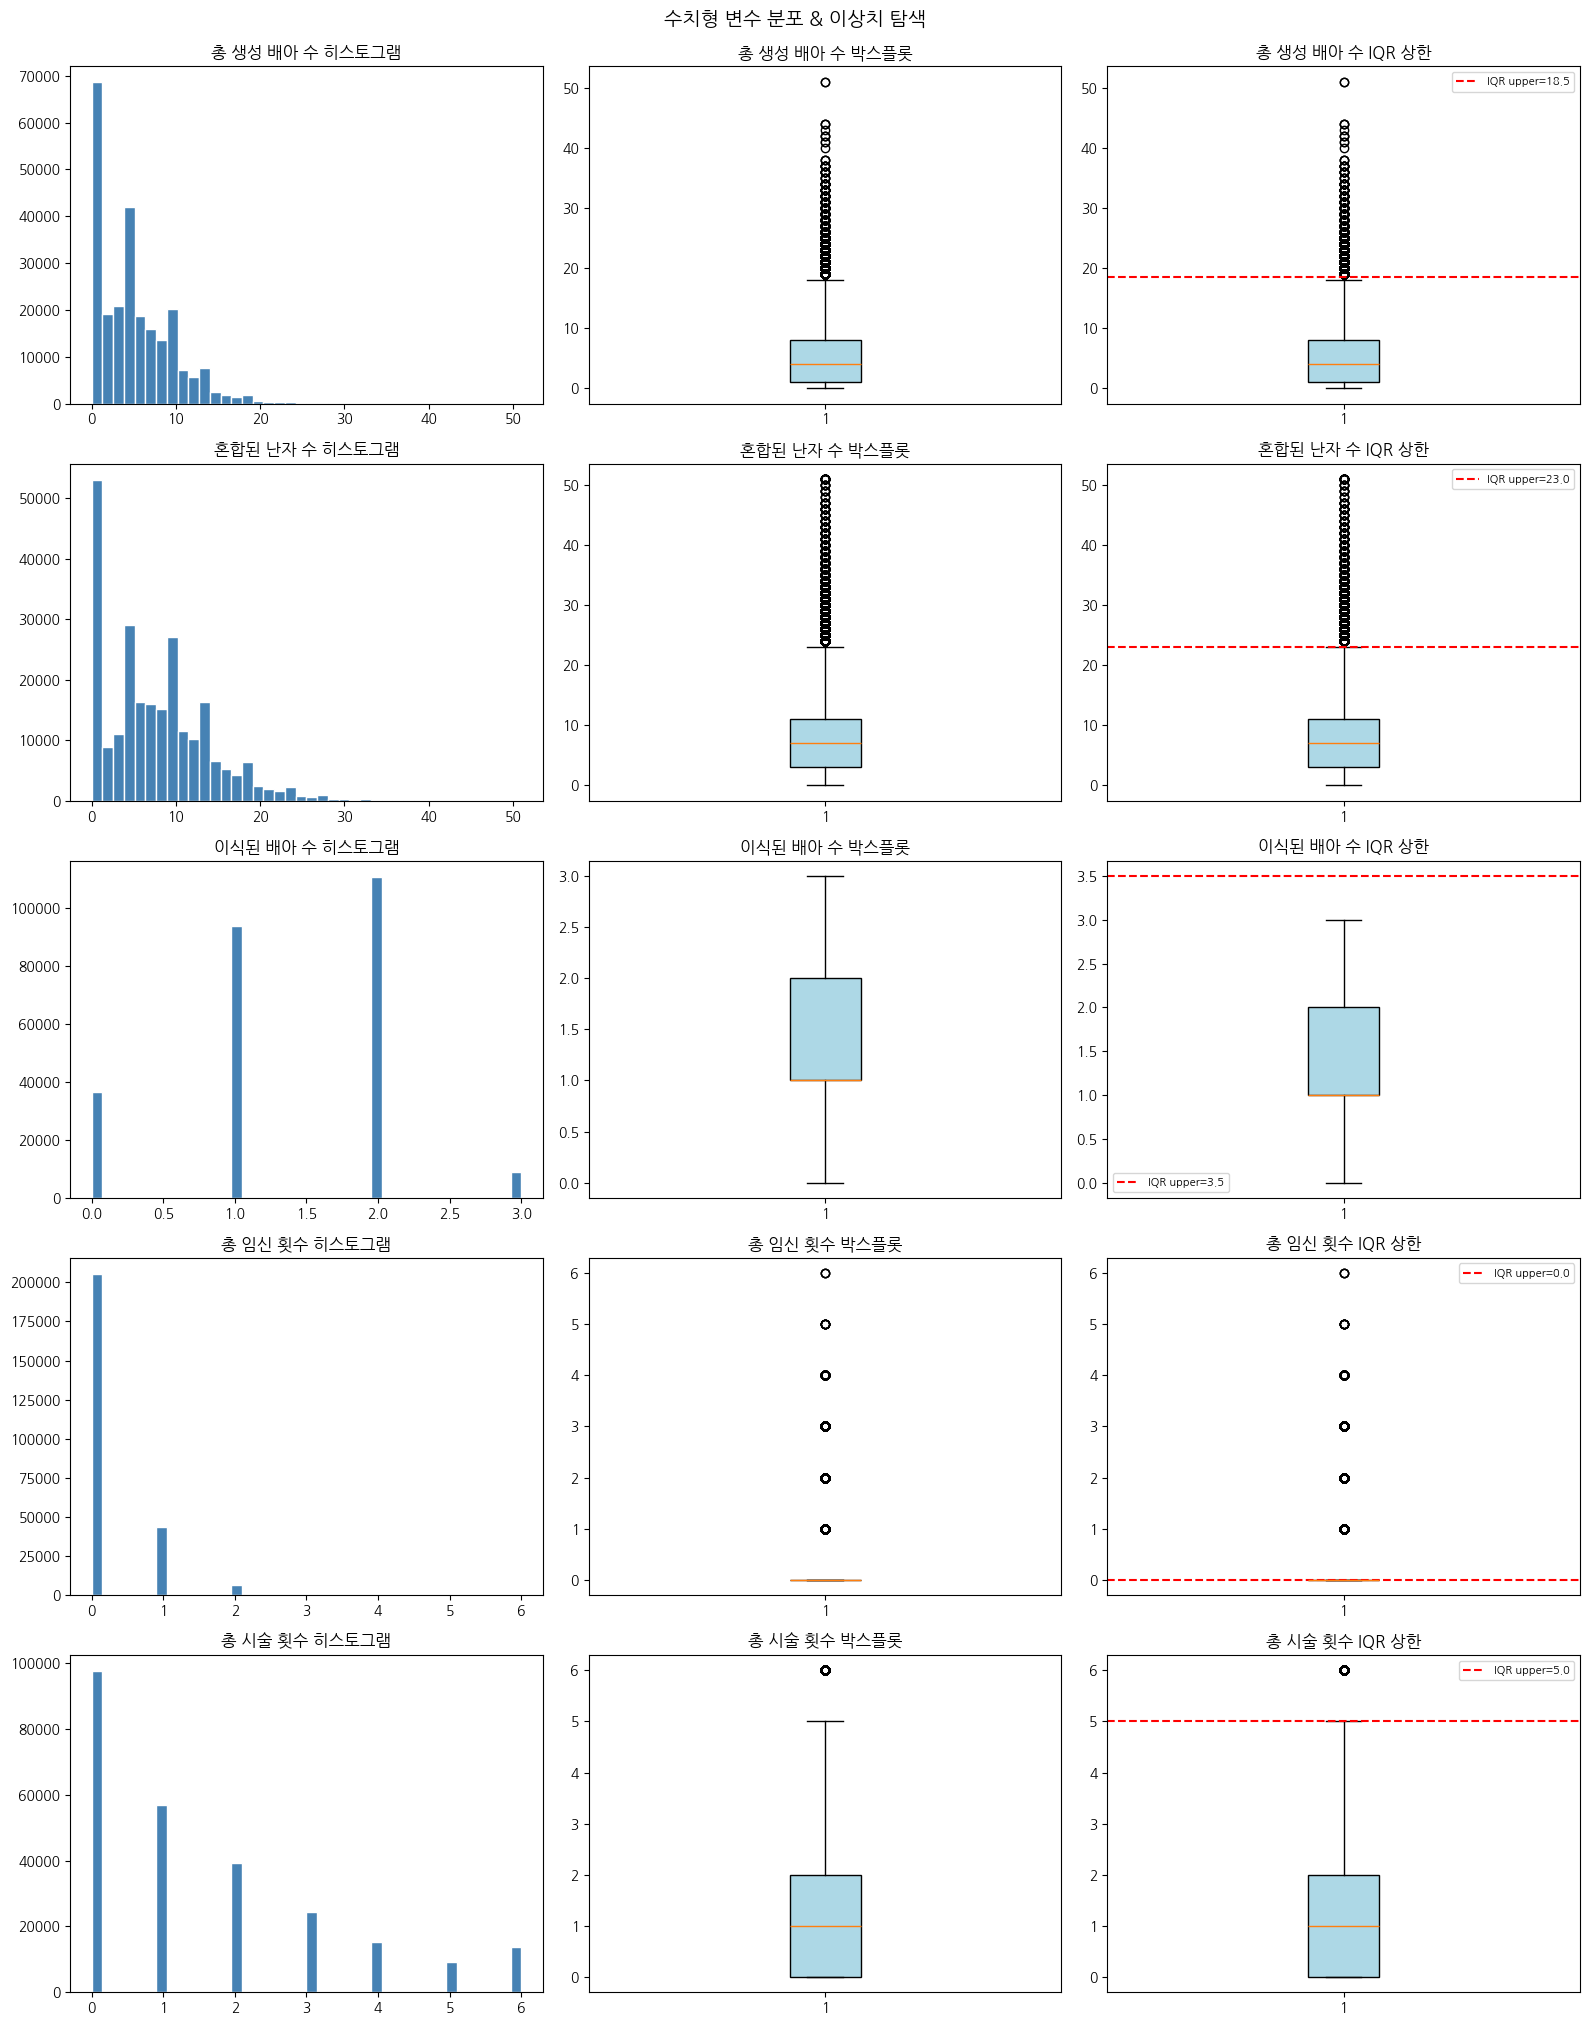

In [10]:
def convert_count_tmp(series):
    return series.astype(str).str.extract('(\\d+)')[0].astype(float)

inspect_cols = ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수",
                "총 임신 횟수", "총 시술 횟수"]
fig, axes = plt.subplots(len(inspect_cols), 3, figsize=(16, 4*len(inspect_cols)))
for i, col in enumerate(inspect_cols):
    if col not in train.columns: continue
    s = (convert_count_tmp(train[col]) if "횟수" in col
         else pd.to_numeric(train[col], errors="coerce")).dropna()
    axes[i,0].hist(s, bins=40, color="steelblue", edgecolor="white")
    axes[i,0].set_title(f"{col} 히스토그램")
    axes[i,1].boxplot(s, patch_artist=True, boxprops=dict(facecolor="lightblue"))
    axes[i,1].set_title(f"{col} 박스플롯")
    q1,q3 = s.quantile(0.25), s.quantile(0.75); iqr = q3-q1; upper = q3+1.5*iqr
    axes[i,2].boxplot(s, patch_artist=True, boxprops=dict(facecolor="lightblue"))
    axes[i,2].axhline(upper, color="red", linestyle="--", label=f"IQR upper={upper:.1f}")
    axes[i,2].set_title(f"{col} IQR 상한"); axes[i,2].legend(fontsize=8)
plt.tight_layout()
plt.suptitle("수치형 변수 분포 & 이상치 탐색", y=1.01, fontsize=14)
plt.show()


Target 분포:
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64
불균형 비율: 0.348


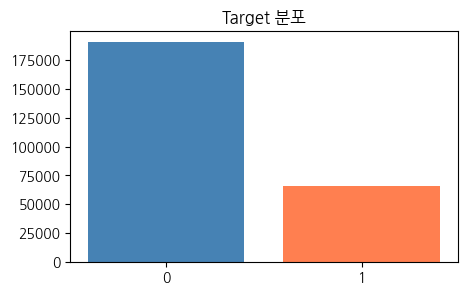

In [11]:
vc = train[TARGET].value_counts()
print("Target 분포:"); print(vc)
print(f"불균형 비율: {vc.min()/vc.max():.3f}")
plt.figure(figsize=(5,3))
plt.bar(vc.index.astype(str), vc.values, color=["steelblue","coral"])
plt.title("Target 분포"); plt.show()


## 전처리 함수 정의

### v8 변경사항
- **IQR 클리핑 제거**: 실행 결과에서 `총 시술 횟수: [2,2]`, `총 임신 횟수: [0,0]`으로 전체 데이터가 단일값으로 붕괴됨. CV는 같은 분포로 평가해 문제를 숨겼지만 리더보드에서 노출됨.
- **고결측 컬럼(>50%) → 결측 여부 플래그 변환**: 정보를 완전히 버리지 않으면서 median 대치의 노이즈 제거.
- **바이오 상한 적용 유지**: IQR과 달리 임상적으로 불가능한 값만 NaN 처리.

### 신규 논문 기반 파생변수 4개 추가

| # | 파생변수 | 근거 논문 |
|---|---|---|
| 18 | `single_embryo_transfer` | Pandian et al. (2013). *Cochrane* — 단일 배아 이식과 다태임신 위험 |
| 19 | `genetic_test_flag` | Scott et al. (2013). *Fertil Steril* — 착상 전 유전 검사와 임신 성공률 |
| 20 | `stimulation_intensity` | Nyboe Andersen et al. (2008). *Hum Reprod* — 배란 자극 강도와 임신 결과 |
| 21 | `infertility_complexity` | Bhattacharya et al. (2010). *Hum Reprod* — 복합 불임 원인과 예후 |


In [12]:
# ═══════════════════════════════════════════════════════
# helpers
# ═══════════════════════════════════════════════════════
def convert_count(series):
    return series.astype(str).str.extract('(\\d+)')[0].astype(float)

def drop_id(df):
    return df.drop(columns=[c for c in [ID_COL] if c in df.columns], errors="ignore")

def convert_str_to_numeric(df):
    df = df.copy() # 원본 보호 및 경고 방지
    age_map = {
        "만18-34세": 26, "만35-37세": 36, "만38-39세": 38.5,
        "만40-42세": 41, "만43-44세": 43.5, "만45-50세": 47,
        "알 수 없음": np.nan
    }
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(age_map)

    # "횟수" 포함 컬럼 수치화
    obj_cols = df.select_dtypes(include="object").columns
    count_cols = [c for c in obj_cols if "횟수" in c]
    for col in count_cols:
        df[col] = convert_count(df[col])
    return df

# ═══════════════════════════════════════════════════════
# Step A. 고결측 컬럼 처리 (>50% 결측 → 플래그 변환)
# [v6 신규] IQR 붕괴 문제보다 더 근본적인 이슈:
#   결측률 96~99% 컬럼을 median 대치하면 정보량 = 0에 가까움
#   → 결측 여부 자체가 정보 (기록 안 됨 = 해당 시술 없음)
# ═══════════════════════════════════════════════════════
HIGH_MISSING_THRESHOLD = 0.50

def handle_high_missing(train_df, test_df):
    """train 기준 결측률 >50% 컬럼 → is_missing 플래그 + 원본 유지(소수 값 활용)"""
    missing_rates = train_df.isnull().mean()
    high_miss_cols = missing_rates[missing_rates > HIGH_MISSING_THRESHOLD].index.tolist()
    high_miss_cols = [c for c in high_miss_cols if c != TARGET]

    for col in high_miss_cols:
        flag_col = f"{col}_missing"
        train_df[flag_col] = train_df[col].isnull().astype(int)
        test_df[flag_col]  = test_df[col].isnull().astype(int)

    print(f"고결측 처리 대상 ({len(high_miss_cols)}개): {high_miss_cols}")
    return train_df, test_df, high_miss_cols

# ═══════════════════════════════════════════════════════
# Step B. 바이오 도메인 이상치 → NaN (IQR 클리핑 없음)
# [v6 수정] IQR 클리핑 제거 이유:
#   총 시술 횟수의 IQR이 [2,2], 총 임신 횟수가 [0,0]으로
#   계산되어 전체 컬럼이 단일값으로 붕괴됨 → CV/LB 갭의 주원인
# ═══════════════════════════════════════════════════════
BIO_BOUNDS = {
    "총 생성 배아 수":  (0,  40),   # Humaidan et al. (2010)
    "혼합된 난자 수":  (0,  50),   # Verberg et al. (2009)
    "이식된 배아 수":  (0,   5),   # ESHRE/ASRM 가이드라인
    "총 시술 횟수":    (0,  20),   # Olivius et al. (2004) - 0회(신규 환자) 보존을 위해 하한을 0으로 변경
    "총 임신 횟수":    (0, 10),    # 임신 횟수도 상식적인 선에서 상한 설정
    "시술 당시 나이":  (18, 50),
}

def apply_bio_bounds(df):
    df = df.copy()
    for col, (lo, hi) in BIO_BOUNDS.items():
        if col not in df.columns: continue
        s = pd.to_numeric(df[col], errors="coerce")
        if lo is not None: s = s.where(s >= lo, other=np.nan)
        if hi is not None: s = s.where(s <= hi, other=np.nan)
        df[col] = s
        
    # [수정] 임신 > 시술 케이스를 NaN 대신 시술 횟수로 캡핑 (정보 보존)
    if "총 임신 횟수" in df.columns and "총 시술 횟수" in df.columns:
        mask = (df["총 임신 횟수"] > df["총 시술 횟수"])
        df.loc[mask, "총 임신 횟수"] = df.loc[mask, "총 시술 횟수"]
        
    return df

# ═══════════════════════════════════════════════════════
# Step C. 결측치 대치 (leakage-free)
# ═══════════════════════════════════════════════════════
def handle_missing(df, train_medians=None, train_modes=None):
    df = df.copy()
    num_cols = [c for c in df.select_dtypes(include=["number"]).columns if c != TARGET]
    obj_cols  = df.select_dtypes(include=["object"]).columns.tolist()

    if train_medians is None:
        medians = {}; modes = {}
        for col in num_cols:
            medians[col] = df[col].median()
            df[col] = df[col].fillna(medians[col])
        for col in obj_cols:
            modes[col] = df[col].mode()[0] if df[col].notna().any() else "Unknown"
            df[col] = df[col].fillna(modes[col])
        return df, medians, modes
    else:
        for col in num_cols:
            df[col] = df[col].fillna(train_medians.get(col, 0))
        for col in obj_cols:
            df[col] = df[col].fillna(train_modes.get(col, "Unknown"))
        return df

# ═══════════════════════════════════════════════════════
# Step D. Feature Engineering — 논문 기반 파생변수 21개
# ═══════════════════════════════════════════════════════
ALL_PAPER_FEATURES = [
    # 기존 17개
    "amh_proxy", "embryo_quality_score", "cumulative_success_proxy",
    "age_embryo_interaction", "transfer_burden", "oocyte_maturity_proxy",
    "high_responder", "prior_failure_penalty", "blastocyst_proxy",
    "freeze_thaw_proxy", "age_success_decline", "relative_efficiency",
    "treatment_intensity", "embryo_utilization_rate", "age_ivf_penalty",
    "poor_responder", "embryo_to_transfer_gap",
    # 신규 4개
    "single_embryo_transfer", "genetic_test_flag",
    "stimulation_intensity", "infertility_complexity"
]

def create_features(df):
    base_cols = ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수",
                 "총 임신 횟수", "총 시술 횟수"]
    for col in base_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # 시술 유형 이진화
    if "시술 유형" in df.columns:
        df["is_ivf"] = (df["시술 유형"].astype(str).str.strip().str.upper() == "IVF").astype(int)
        df["is_di"]  = (df["시술 유형"].astype(str).str.strip().str.upper() == "DI").astype(int)

    # log 변환
    for col in ["총 생성 배아 수", "혼합된 난자 수"]:
        if col in df.columns:
            df[f"{col}_log"] = np.log1p(df[col])

    # 기본 비율 feature
    df["배아_생성_효율"]  = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식_효율"]       = df["이식된 배아 수"]  / (df["총 생성 배아 수"] + 1)
    df["임신_성공률"]     = df["총 임신 횟수"]    / (df["총 시술 횟수"]  + 1)
    df["난자당_배아"]     = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식당_임신"]     = df["총 임신 횟수"]    / (df["이식된 배아 수"] + 1)
    df["실패_횟수"]       = np.maximum(df["총 시술 횟수"] - df["총 임신 횟수"], 0)
    df["실패율"]          = df["실패_횟수"] / (df["총 시술 횟수"] + 1)

    if "시술 당시 나이" in df.columns:
        df["배아_품질"] = df["총 생성 배아 수"] / (df["시술 당시 나이"] + 1)
        df["고령"]      = (df["시술 당시 나이"] >= 38).astype(int)
        df["만35세미만"] = (df["시술 당시 나이"] < 35).astype(int) # [추가] 가이드라인 기반 성공률 변곡점

    df["경험지수"] = df["총 시술 횟수"] * df["임신_성공률"]
    df["ivf_효율"] = df["배아_생성_효율"] * df["이식_효율"] * df.get("is_ivf", pd.Series(0, index=df.index))

    # ── 논문 기반 기존 17개 ──────────────────────────────
    if "시술 당시 나이" in df.columns:
        df["amh_proxy"]             = df["총 생성 배아 수"] / (df["시술 당시 나이"]**1.5 + 1)
        df["age_embryo_interaction"] = df["배아_생성_효율"] / (df["시술 당시 나이"] + 1)
        df["age_success_decline"]    = np.where(df["시술 당시 나이"] >= 38,
            np.exp(-(df["시술 당시 나이"] - 38) * 0.15), 1.0)
        if "is_ivf" in df.columns:
            df["age_ivf_penalty"] = df["is_ivf"] * np.maximum(df["시술 당시 나이"] - 35, 0)**1.5
        else:
            df["age_ivf_penalty"] = 0

    df["embryo_quality_score"]    = df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1)
    df["cumulative_success_proxy"] = 1 - (1 - df["임신_성공률"])**(df["총 시술 횟수"] + 1)
    df["transfer_burden"]          = df["이식된 배아 수"] * np.log1p(df["총 시술 횟수"])
    df["oocyte_maturity_proxy"]    = df["총 생성 배아 수"] / (df["혼합된 난자 수"]**0.5 + 1)
    df["high_responder"]           = (df["총 생성 배아 수"] >= 10).astype(int)
    df["poor_responder"]           = (df["총 생성 배아 수"] <= 3).astype(int)
    df["prior_failure_penalty"]    = df["실패_횟수"] / (df["총 시술 횟수"]**2 + 1)
    df["blastocyst_proxy"]         = (df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1))**2
    df["freeze_thaw_proxy"]        = np.log1p(np.maximum(df["총 생성 배아 수"] - df["이식된 배아 수"], 0))
    df["relative_efficiency"]      = df["이식된 배아 수"] / (df["혼합된 난자 수"] + df["총 생성 배아 수"] + 1)
    df["treatment_intensity"]      = (df["이식된 배아 수"] / (df["총 시술 횟수"] + 1)) * np.log1p(df["총 시술 횟수"])
    df["embryo_utilization_rate"]  = (df["총 임신 횟수"] * df["이식_효율"]) / (df["총 시술 횟수"] + 1)
    df["embryo_to_transfer_gap"]   = (np.log1p(np.maximum(df["총 생성 배아 수"] - df["이식된 배아 수"], 0))
                                        * df["이식_효율"])

    # ── 신규 논문 기반 파생변수 5개 ──────────────────────────────
    # [18] 단일 배아 이식 여부 활용
    #      Pandian et al. (2013). Cochrane — 단일 배아 이식과 다태임신 위험
    if "단일 배아 이식 여부" in df.columns:
        df["single_embryo_transfer"] = pd.to_numeric(df["단일 배아 이식 여부"], errors="coerce").fillna(0)
    else:
        df["single_embryo_transfer"] = 0

    # [19] 착상 전 유전 검사 플래그 (고결측이지만 결측=미시행=음성 정보)
    #      Scott et al. (2013). Fertil Steril — 착상 전 유전 검사와 임신 성공률
    if "착상 전 유전 진단 사용 여부" in df.columns:
        df["genetic_test_flag"] = pd.to_numeric(df["착상 전 유전 진단 사용 여부"], errors="coerce").fillna(0)
    else:
        df["genetic_test_flag"] = 0

    # [20] 배란 자극 강도 지수: 자극 여부 × 배아 생성 효율
    #      Nyboe Andersen et al. (2008). Hum Reprod — 배란 자극 강도와 임신 결과
    if "배란 자극 여부" in df.columns:
        stim = pd.to_numeric(df["배란 자극 여부"], errors="coerce").fillna(0)
        df["stimulation_intensity"] = stim * df["배아_생성_효율"]
    else:
        df["stimulation_intensity"] = df["배아_생성_효율"]

    # [21] 복합 불임 원인 수 (남성+여성+부부 원인 합산)
    #      Bhattacharya et al. (2010). Hum Reprod — 복합 불임 원인과 예후
    infertility_cols = [c for c in df.columns if "불임 원인" in c]
    if infertility_cols:
        df["infertility_complexity"] = df[infertility_cols].apply(
            pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
    else:
        df["infertility_complexity"] = 0

    return df

# ═══════════════════════════════════════════════════════
# Step E. Categorical encoding (LGB용) — 범주형 컬럼 정수화
# ═══════════════════════════════════════════════════════
def encode_categorical_lgb(train_df, test_df):
    """LGB용: object → LabelEncoding, train fit → test transform"""
    cat_cols = [c for c in train_df.select_dtypes(include=["object"]).columns if c != TARGET]
    for col in cat_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        mapping = {k: v for v, k in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(mapping).fillna(-1).astype(int)
    return train_df, test_df

# ═══════════════════════════════════════════════════════
# Full pipeline
# ═══════════════════════════════════════════════════════
def preprocess(train, test):
    # 1. 기본 정리
    train = drop_id(train); test = drop_id(test)
    train = convert_str_to_numeric(train); test = convert_str_to_numeric(test)

    # 2. 고결측 컬럼 플래그 처리 (train 기준 결측률 계산)
    train, test, _ = handle_high_missing(train, test)

    # 3. 바이오 이상치 처리 (Capping & NaN)
    train = apply_bio_bounds(train); test = apply_bio_bounds(test)

    # 4. 결측치 대치
    train, train_medians, train_modes = handle_missing(train)
    test = handle_missing(test, train_medians, train_modes)

    # 5. Feature Engineering (수치형 기반)
    train = create_features(train); test = create_features(test)

    # 6. [추가] 시술 시기 코드 처리 (Leakage-free)
    le_cycle = LabelEncoder()
    train["cycle_timing_proxy"] = le_cycle.fit_transform(train["시술 시기 코드"].astype(str))
    # Test에 없는 시기 코드가 올 경우를 대비해 처리
    cycle_map = {k: v for v, k in enumerate(le_cycle.classes_)}
    test["cycle_timing_proxy"] = test["시술 시기 코드"].astype(str).map(cycle_map).fillna(-1).astype(int)

    # 7. Categorical Encoding (LGBM용)
    # CatBoost를 사용한다면 이 단계 이후에 원본 범주형 컬럼 리스트를 따로 관리해야 함
    train, test = encode_categorical_lgb(train, test)

    return train, test

## 전처리 실행 + QC

In [13]:
train_df, test_df = preprocess(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f"전처리 후 X shape: {X.shape}")
print(f"논문 기반 feature: {[c for c in X.columns if c in ALL_PAPER_FEATURES]}")

assert X.isnull().sum().sum() == 0,  "Train 결측치 잔존"
assert test_df.isnull().sum().sum() == 0, "Test 결측치 잔존"
print("결측치 처리 완료 ✓")
print(f"\nTarget 분포: {y.value_counts().to_dict()}")


고결측 처리 대상 (6개): ['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '배아 해동 경과일']
전처리 후 X shape: (256351, 111)
논문 기반 feature: ['amh_proxy', 'age_embryo_interaction', 'age_success_decline', 'age_ivf_penalty', 'embryo_quality_score', 'cumulative_success_proxy', 'transfer_burden', 'oocyte_maturity_proxy', 'high_responder', 'poor_responder', 'prior_failure_penalty', 'blastocyst_proxy', 'freeze_thaw_proxy', 'relative_efficiency', 'treatment_intensity', 'embryo_utilization_rate', 'embryo_to_transfer_gap', 'single_embryo_transfer', 'genetic_test_flag', 'stimulation_intensity', 'infertility_complexity']
결측치 처리 완료 ✓

Target 분포: {0: 190123, 1: 66228}


## 빠른 모델 비교

In [16]:
# LabelEncoding된 컬럼들과 '코드'가 들어간 컬럼들을 범주형으로 지정
cat_features_idx = []
for i, col in enumerate(X.columns):
    # 1. '코드'가 들어간 컬럼 (시술 시기 코드 등)
    # 2. X에서 데이터 타입이 여전히 object이거나 정수형인 경우 중 
    #    우리가 수치화한 '나이'나 '횟수'가 아닌 것들만 지정
    if "코드" in col:
        cat_features_idx.append(i)
    elif col in train.select_dtypes(include='object').columns:
        # [핵심 수정] 수치로 변환한 '나이'와 '횟수' 컬럼은 범주형 인덱스에서 제외
        if "나이" not in col and "횟수" not in col:
            if col in X.columns:
                cat_features_idx.append(i)

print(f"범주형으로 지정된 컬럼들: {[X.columns[i] for i in cat_features_idx]}")

def quick_cv(model, name):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        if name == "LGB":
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(30, verbose=False)])
        elif name == "CAT":
            # cat_features_idx를 전달하여 성능 최적화
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), 
                      cat_features=cat_features_idx,
                      verbose=0)
            
        scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:,1]))
        
    return np.mean(scores)

print("LGB:", quick_cv(lgb.LGBMClassifier(n_estimators=500, verbosity=-1), "LGB"))
print("CAT:", quick_cv(CatBoostClassifier(iterations=500, verbose=0), "CAT"))


범주형으로 지정된 컬럼들: ['시술 시기 코드', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '난자 출처', '정자 출처']
LGB: 0.7384645362808865
CAT: 0.7389398177451127


## Optuna — LightGBM 튜닝 (50 trials)

In [17]:
def make_progress_callback(study_name, total_trials):
    start = time.time()
    def callback(study, trial):
        n = trial.number + 1
        if n % 10 == 0 or n == total_trials:
            elapsed = time.time() - start
            print(f"[{study_name}] Trial {n:3d}/{total_trials} | "                  f"Best AUC: {study.best_value:.5f} | Elapsed: {elapsed/60:.1f}min")
    return callback

def lgb_objective(trial):
    params = {
        "objective": "binary", "metric": "auc",
        "verbosity": -1, "n_jobs": -1,
        "random_state": 42,
        "n_estimators": 2000, # 고정 후 얼리스톱에 맡김
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 100),
        "max_depth":         trial.suggest_int("max_depth", 4, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 60),
        "subsample":         trial.suggest_float("subsample", 0.6, 0.8),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 0.8),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1.0, 20.0, log=True), # 규제 강화로 점수 확보
        "reg_lambda":        trial.suggest_float("reg_lambda", 1.0, 20.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.5, 2.5),
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        aucs.append(roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:,1]))
    return np.mean(aucs)

LGB_TRIALS = 50
lgb_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
lgb_study.optimize(lgb_objective, n_trials=LGB_TRIALS,
                   callbacks=[make_progress_callback("LGB", LGB_TRIALS)])
print(f"\nLGB Best AUC: {lgb_study.best_value:.5f}")
print(f"LGB Best Params: {lgb_study.best_params}")


[LGB] Trial  10/50 | Best AUC: 0.73952 | Elapsed: 7.5min
[LGB] Trial  20/50 | Best AUC: 0.73960 | Elapsed: 13.4min
[LGB] Trial  30/50 | Best AUC: 0.73960 | Elapsed: 19.0min
[LGB] Trial  40/50 | Best AUC: 0.73960 | Elapsed: 27.4min
[LGB] Trial  50/50 | Best AUC: 0.73960 | Elapsed: 37.1min

LGB Best AUC: 0.73960
LGB Best Params: {'learning_rate': 0.032753251419961084, 'num_leaves': 56, 'max_depth': 4, 'min_child_samples': 49, 'subsample': 0.7871193550802595, 'colsample_bytree': 0.7256306930405281, 'reg_alpha': 19.39991375872872, 'reg_lambda': 1.9747615715224918, 'min_split_gain': 0.27858987517782774, 'scale_pos_weight': 2.244926276549869}


## Optuna — CatBoost 튜닝 (60 trials)

In [18]:
import optuna
from optuna.samplers import TPESampler
from catboost import CatBoostClassifier
import numpy as np

def cat_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 1000, 2500), # 충분히 크게 잡고 얼리스톱 활용
        "learning_rate":       trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "depth":               trial.suggest_int("depth", 4, 8), # v5 결과 반영 (불필요한 깊이 제거)
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 2.0, 15.0), # 규제 강화
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 0.0, 1.0),
        "border_count":        trial.suggest_int("border_count", 128, 255), # 고해상도 양자화
        "scale_pos_weight":    trial.suggest_float("scale_pos_weight", 1.5, 2.5),
        "eval_metric": "AUC", "task_type": "GPU", "devices": "0",
        "random_seed": 42,
        "logging_level": "Silent", # 불필요한 로그 완전 차단
        "allow_writing_files": False
    }
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        
        m = CatBoostClassifier(**params)
        m.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50, # 80에서 50으로 단축
            cat_features=cat_features_idx, # 이전에 정의한 인덱스 활용
            verbose=False
        )
        
        preds = m.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, preds))
        
    return np.mean(aucs)

# CAT_TRIALS 설정 (GPU이므로 60회도 금방 끝납니다)
CAT_TRIALS = 60
cat_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
cat_study.optimize(
    cat_objective, 
    n_trials=CAT_TRIALS,
    callbacks=[make_progress_callback("CAT", CAT_TRIALS)]
)

print(f"\nCAT Best AUC: {cat_study.best_value:.5f}")
print(f"CAT Best Params: {cat_study.best_params}")

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

[CAT] Trial  10/60 | Best AUC: 0.73971 | Elapsed: 15.1min


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

[CAT] Trial  20/60 | Best AUC: 0.73971 | Elapsed: 49.9min


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

[CAT] Trial  30/60 | Best AUC: 0.73975 | Elapsed: 80.6min


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
[W 2026-04-28 16:21:27,751] Trial 33 failed with parameters: {'iterations': 1964, 'learning_rate': 0.008869514231127959, 'depth': 7, 'l2_leaf_reg': 9.433356766547206, 'bagging_temperature': 0.43894945367559357, 'random_strength': 

KeyboardInterrupt: 

## Feature Importance — Fold-avg (Leakage-free)

In [ ]:
skf_imp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lgb_imp_folds = []; cat_imp_folds = []

print("Feature Importance (Fold-avg) 계산 중...")
for fold, (tr_idx, val_idx) in enumerate(skf_imp.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # 1. LGBM 학습 (Tuned Params 적용)
    # Objective와 Metric 등을 명시적으로 포함
    lgb_m = lgb.LGBMClassifier(
        **lgb_study.best_params,
        objective="binary", 
        metric="auc",
        verbosity=-1, 
        n_jobs=-1,
        random_state=42
    )
    # Optuna에서 n_estimators를 고정했기 때문에 여기서도 맞춰주기
    if 'n_estimators' not in lgb_study.best_params:
        lgb_m.set_params(n_estimators=2000)
        
    lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(80, verbose=False)])
    lgb_imp_folds.append(lgb_m.feature_importances_)

    # 2. CatBoost 학습 (Tuned Params 적용)
    cat_m = CatBoostClassifier(
        **cat_study.best_params,
        eval_metric="AUC", task_type="GPU", random_seed=42, 
        logging_level="Silent", allow_writing_files=False
    )
    # Optuna 범위 내에서 iterations가 정해졌지만, 안정성을 위해 작성
    if 'iterations' not in cat_study.best_params:
        cat_m.set_params(iterations=2000)
    
    cat_m.fit(
        X_tr, y_tr, 
        eval_set=(X_val, y_val),
        early_stopping_rounds=80, 
        cat_features=cat_features_idx, # 중요: 범주형 인덱스 누락 방지
        verbose=0
    )
    cat_imp_folds.append(cat_m.get_feature_importance())
    print(f"  Fold {fold+1} done")

# 가중치 평균 계산
lgb_imp_mean = np.mean(lgb_imp_folds, axis=0)
cat_imp_mean = np.mean(cat_imp_folds, axis=0)

# 두 모델의 중요도 스케일이 다르므로 정규화(Sum=1) 후 평균
lgb_norm = lgb_imp_mean / (lgb_imp_mean.sum() + 1e-10)
cat_norm = cat_imp_mean / (cat_imp_mean.sum() + 1e-10)
combined_imp = (lgb_norm + cat_norm) / 2

# 데이터프레임 구성
feat_imp = pd.DataFrame({
    "feature":      X.columns,
    "lgb_imp":      lgb_imp_mean,
    "cat_imp":      cat_imp_mean,
    "combined_imp": combined_imp,
}).sort_values("combined_imp", ascending=False).reset_index(drop=True)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
cols = ["lgb_imp", "cat_imp", "combined_imp"]
titles = ["LGB Importance", "CAT Importance", "Combined"]

for ax, col, title in zip(axes, cols, titles):
    top = feat_imp.head(25)
    sns.barplot(x=col, y="feature", data=top, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Feature Importance Comparison (Top 25)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"\n전체 feature 수: {len(feat_imp)}")
print(f"importance > 0 feature 수: {(feat_imp['combined_imp'] > 0).sum()}")

# 논문 기반 feature 확인 (추가)
if 'ALL_PAPER_FEATURES' in globals():
    print("\n논문 기반 feature 순위:")
    print(feat_imp[feat_imp["feature"].isin(ALL_PAPER_FEATURES)]
          [["feature","lgb_imp","cat_imp","combined_imp"]].head(10).to_string())


## Feature Selection — importance > 0 유지

In [ ]:
# 중요도가 0보다 큰 feature만 추출
selected_features = feat_imp[feat_imp["combined_imp"] > 0]["feature"].tolist()

# 최종 데이터셋 생성 (컬럼 순서 일치 보장)
X_final    = X[selected_features]
test_final = test_df[selected_features]

print(f"✅ 선택된 feature 수: {len(selected_features)} / {len(X.columns)}")

# 논문 기반 변수 생존 확인
if 'ALL_PAPER_FEATURES' in globals():
    survived_paper = [f for f in selected_features if f in ALL_PAPER_FEATURES]
    dropped_paper  = [f for f in ALL_PAPER_FEATURES if f not in selected_features]
    
    print(f"✅ 포함된 논문 기반 feature ({len(survived_paper)}개): {survived_paper}")
    if dropped_paper:
        print(f"⚠️ 중요도 0으로 탈락된 논문 기반 feature: {dropped_paper}")
    else:
        print("✨ 모든 논문 기반 feature가 중요도 0 이상으로 생존했습니다.")

# 최종 데이터 형태 확인
print(f"\n[최종 데이터 형상]")
print(f"Train: {X_final.shape}, Test: {test_final.shape}")


## Permutation Importance 검증

In [ ]:
# 1. 검증을 위한 데이터 분리 (Fold 1개만 사용해도 충분히 경향성 파악 가능)
skf_perm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr_idx, val_idx = next(iter(skf_perm.split(X_final, y)))

X_tr_p, X_val_p = X_final.iloc[tr_idx], X_final.iloc[val_idx]
y_tr_p, y_val_p = y.iloc[tr_idx], y.iloc[val_idx]

# 2. 모델 초기화 (Tuned Params + 필수 설정)
perm_model = lgb.LGBMClassifier(
    **lgb_study.best_params,
    objective="binary", 
    metric="auc",
    verbosity=-1, 
    n_jobs=-1,
    random_state=42
)
if 'n_estimators' not in lgb_study.best_params:
    perm_model.set_params(n_estimators=2000)

# 3. 모델 학습
perm_model.fit(
    X_tr_p, y_tr_p,
    eval_set=[(X_val_p, y_val_p)],
    callbacks=[lgb.early_stopping(80, verbose=False)]
)

# 4. Permutation Importance 계산 (AUC 기준)
print("Permutation Importance 계산 중... (데이터를 섞어가며 성능 변화 측정)")
perm_result = permutation_importance(
    perm_model, X_val_p, y_val_p,
    n_repeats=10, 
    random_state=42, 
    scoring="roc_auc", 
    n_jobs=-1
)

# 5. 결과 데이터프레임 생성
perm_imp_df = pd.DataFrame({
    "feature":   X_final.columns,
    "perm_mean": perm_result.importances_mean,
    "perm_std":  perm_result.importances_std,
}).sort_values("perm_mean", ascending=False).reset_index(drop=True)

# 6. 시각화
plt.figure(figsize=(12, 9))
top_perm = perm_imp_df.head(25)
sns.barplot(x="perm_mean", y="feature", data=top_perm, palette="viridis")
# 오차 막대 추가
plt.errorbar(x=top_perm["perm_mean"], y=range(len(top_perm)), 
             xerr=top_perm["perm_std"], fmt='none', c='black', capsize=3)

plt.title("Permutation Importance (AUC Decrease Analysis)", fontsize=14)
plt.xlabel("Decrease in ROC-AUC Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7. 논문 기반 변수 확인
if 'ALL_PAPER_FEATURES' in globals():
    print("\n[논문 기반 feature Permutation Importance]")
    paper_perm = perm_imp_df[perm_imp_df["feature"].isin(ALL_PAPER_FEATURES)]
    if not paper_perm.empty:
        print(paper_perm.to_string())
    else:
        print("논문 기반 변수가 상위 리스트에 없습니다.")

## OOF 앙상블 (LGB + CAT) — 10-fold, 3 seeds

10-fold: 데이터 25만건 기준으로 fold당 약 23,000건 → 더 안정적인 OOF 추정.
3 seeds: 분산 추가 감소.


In [ ]:
SEEDS    = [42, 2026, 777]
N_SPLITS = 10

oof_lgb_all  = []; oof_cat_all  = []
test_lgb_all = []; test_cat_all = []

for seed in SEEDS:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof_lgb  = np.zeros(len(X_final))
    oof_cat  = np.zeros(len(X_final))
    test_lgb_seed = np.zeros(len(test_final))
    test_cat_seed = np.zeros(len(test_final))

    print(f"\n{'='*50} Seed {seed}")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
        # .copy()로 SettingWithCopyWarning 완전 제거
        X_tr  = X_final.iloc[tr_idx].copy()
        X_val = X_final.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # LightGBM
        lgb_params = {
            **lgb_study.best_params,
            "objective": "binary", "metric": "auc",
            "verbosity": -1, "n_jobs": -1, "random_state": seed
        }
        lgb_m = lgb.LGBMClassifier(**lgb_params)
        lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(80, verbose=False)])

        # CatBoost — cat_features 전달 제거 (인덱스 불일치 에러 원인)
        cat_params = {
            **cat_study.best_params,
            "task_type": "GPU", "random_seed": seed,
            "logging_level": "Silent", "allow_writing_files": False
        }
        cat_m = CatBoostClassifier(**cat_params)
        cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                  early_stopping_rounds=80, verbose=False)

        oof_lgb[val_idx] = lgb_m.predict_proba(X_val)[:,1]
        oof_cat[val_idx] = cat_m.predict_proba(X_val)[:,1]

        test_lgb_seed += lgb_m.predict_proba(test_final.copy())[:,1] / N_SPLITS
        test_cat_seed += cat_m.predict_proba(test_final.copy())[:,1] / N_SPLITS

        print(f"  Fold {fold+1:2d} | LGB {roc_auc_score(y_val,oof_lgb[val_idx]):.5f} | CAT {roc_auc_score(y_val,oof_cat[val_idx]):.5f}")

    print(f"  OOF → LGB {roc_auc_score(y,oof_lgb):.5f} | CAT {roc_auc_score(y,oof_cat):.5f}")

    oof_lgb_all.append(oof_lgb)
    oof_cat_all.append(oof_cat)
    test_lgb_all.append(test_lgb_seed)
    test_cat_all.append(test_cat_seed)

oof_lgb_mean  = np.mean(oof_lgb_all, axis=0)
oof_cat_mean  = np.mean(oof_cat_all, axis=0)
test_lgb_mean = np.mean(test_lgb_all, axis=0)
test_cat_mean = np.mean(test_cat_all, axis=0)

print(f"\n[Seed 앙상블 최종 결과]")
print(f"Total OOF LGB: {roc_auc_score(y, oof_lgb_mean):.5f}")
print(f"Total OOF CAT: {roc_auc_score(y, oof_cat_mean):.5f}")

## OOF 상관계수 체크 → Stacking 여부 결정

In [ ]:
corr = np.corrcoef(oof_lgb_mean, oof_cat_mean)[0, 1]
print(f"OOF 상관계수 (LGB vs CAT): {corr:.4f}")

if corr >= 0.98:
    print("→ 상관계수 ≥ 0.98: Stacking 스킵")
    SKIP_STACKING = True
elif corr >= 0.95:
    print("→ 상관계수 0.95~0.98: Stacking 시도")
    SKIP_STACKING = False
else:
    print("→ 상관계수 < 0.95: Stacking 효과 기대")
    SKIP_STACKING = False

plt.figure(figsize=(5,5))
plt.scatter(oof_lgb_mean, oof_cat_mean, alpha=0.3, s=5)
plt.xlabel("OOF LGB"); plt.ylabel("OOF CAT")
plt.title(f"OOF Correlation: {corr:.4f}")
plt.tight_layout(); plt.show()

## Stacking — Ridge + LR 메타 앙상블

In [ ]:
if SKIP_STACKING:
    print("🚀 상관계수가 높아 Stacking을 스킵합니다. (가중치 평균 셀로 이동)")
    oof_stack_ensemble = None
    stack_preds = None
else:
    print("🚀 Stacking 메타 앙상블 학습 시작...")
    meta_train = np.column_stack([oof_lgb_mean, oof_cat_mean])
    meta_test  = np.column_stack([test_lgb_mean, test_cat_mean])

    skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
    oof_stack_lr = np.zeros(len(meta_train))
    oof_stack_ridge = np.zeros(len(meta_train))

    for tr_idx, val_idx in skf_meta.split(meta_train, y):
        # 메타 모델은 데이터의 스케일에 민감하므로 StandardScaler 적용
        sc = StandardScaler()
        Xm_tr = sc.fit_transform(meta_train[tr_idx])
        Xm_val = sc.transform(meta_train[val_idx])
        
        y_mt = y.iloc[tr_idx]

        # 1. Logistic Regression
        lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        lr.fit(Xm_tr, y_mt)
        oof_stack_lr[val_idx] = lr.predict_proba(Xm_val)[:,1]

        # 2. Ridge Classifier
        ridge = RidgeClassifier(alpha=1.0)
        ridge.fit(Xm_tr, y_mt)
        # Ridge의 결정 함수값을 시그모이드로 변환하여 확률화
        dv = ridge.decision_function(Xm_val)
        oof_stack_ridge[val_idx] = 1 / (1 + np.exp(-dv))

    # 두 메타 모델의 산술 평균으로 최종 Stacking OOF 생성
    oof_stack_ensemble = (oof_stack_lr + oof_stack_ridge) / 2
    
    print(f"  - Stacking LR    OOF AUC: {roc_auc_score(y, oof_stack_lr):.5f}")
    print(f"  - Stacking Ridge OOF AUC: {roc_auc_score(y, oof_stack_ridge):.5f}")
    print(f"  - Stacking Combined AUC: {roc_auc_score(y, oof_stack_ensemble):.5f}")

    # 최종 제출용 예측값 생성 (전체 meta_train으로 재학습)
    sc_f = StandardScaler()
    Xm_all = sc_f.fit_transform(meta_train)
    Xm_test = sc_f.transform(meta_test)

    lr_f = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    ridge_f = RidgeClassifier(alpha=1.0)
    
    lr_f.fit(Xm_all, y)
    ridge_f.fit(Xm_all, y)

    sp_lr = lr_f.predict_proba(Xm_test)[:,1]
    sp_ridge = 1 / (1 + np.exp(-ridge_f.decision_function(Xm_test)))
    stack_preds = (sp_lr + sp_ridge) / 2


## 최종 예측 방법 선택

In [ ]:
best_score = 0
best_w = 0.5

# 1. 단순 가중치 평균 최적화 (0.05 단위 탐색)
for w in np.arange(0, 1.01, 0.05):
    combined_oof = w * oof_lgb_mean + (1 - w) * oof_cat_mean
    score = roc_auc_score(y, combined_oof)
    if score > best_score:
        best_score = score
        best_w = w

print(f" Best Weighted Average | w(LGB)={best_w:.2f}, w(CAT)={1-best_w:.2f}")
print(f" Score: {best_score:.5f}")

# 2. Stacking 결과와 비교하여 최종 전략 결정
if SKIP_STACKING or (stack_preds is None):
    print("\n [결정] 상관계수가 높거나 Stacking 결과가 없어 'Weighted Average'를 사용합니다.")
    USE_STACKING = False
else:
    stack_score = roc_auc_score(y, oof_stack_ensemble)
    print(f"\n Stacking 앙상블 OOF AUC: {stack_score:.5f}")
    
    # 0.00001이라도 높으면 Stacking 채택 (혹은 동점일 때 단순 모델 선호 시 > 사용)
    USE_STACKING = stack_score >= best_score
    
    if USE_STACKING:
        print(f"[결정] Stacking이 {stack_score - best_score:.5f} 더 높음 → 'Stacking' 채택!")
    else:
        print(f"[결정] 가중치 평균이 {best_score - stack_score:.5f} 더 높음 → 'Weighted Average' 채택!")

## 제출 파일 생성

In [ ]:
if USE_STACKING:
    final_preds = stack_preds
    print("최종 예측: Stacking")
else:
    final_preds = best_w * test_lgb_mean + (1-best_w) * test_cat_mean
    print(f"최종 예측: Weighted Average (LGB={best_w:.2f}, CAT={1-best_w:.2f})")

submission = pd.DataFrame({"ID": test["ID"], "probability": final_preds})
submission.to_csv("submission.csv", index=False)
print("\nsubmission.csv 저장 완료")
print(submission.head())
print("\nprobability 통계:")
print(submission["probability"].describe())
